In [1]:
from dotenv import load_dotenv

load_dotenv(override=True)

True

## Summarize messages

### 机制说明

`SummarizationMiddleware` 是 LangChain 的内置中间件，通过 `create_agent` 的 `middleware=[]` 参数注入，在 Agent 接收消息**之前**自动压缩历史对话。

**工作流程：**

```
invoke() → 中间件链 → Agent LLM → 响应
               ↑
    中间件在 LLM 收到消息前读取并修改 state
```

**关键参数：**

| 参数 | 说明 |
|------|------|
| `model` | 用于生成摘要的模型 |
| `trigger=("tokens", N)` | 上下文超过 N tokens 时触发压缩 |
| `keep=("messages", N)` | 保留最近 N 条原始消息，其余压缩为摘要 |

**摘要输出格式：** 压缩后生成一条 `HumanMessage`，包含四个结构化字段：
- `SESSION INTENT`：用户意图
- `SUMMARY`：对话要点
- `ARTIFACTS`：产出物
- `NEXT STEPS`：后续步骤

并附加 `lc_source: 'summarization'` 标记以标识来源。

> **注意：** checkpointer 中始终保留完整历史，只有转发给 LLM 的上下文被压缩，不影响持久化存储。

In [2]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import SummarizationMiddleware

agent = create_agent(
    model="gpt-5-nano",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-4o-mini",
            trigger=("tokens", 100),
            keep=("messages", 1)
        )
    ],
)

In [3]:
from langchain.messages import HumanMessage, AIMessage
from pprint import pprint

response = agent.invoke(
    {"messages": [
        HumanMessage(content="What is the capital of the moon?"),
        AIMessage(content="The capital of the moon is Lunapolis."),
        HumanMessage(content="What is the weather in Lunapolis?"),
        AIMessage(content="Skies are clear, with a high of 120C and a low of -100C."),
        HumanMessage(content="How many cheese miners live in Lunapolis?"),
        AIMessage(content="There are 100,000 cheese miners living in Lunapolis."),
        HumanMessage(content="Do you think the cheese miners' union will strike?"),
        AIMessage(content="Yes, because they are unhappy with the new president."),
        HumanMessage(content="If you were Lunapolis' new president how would you respond to the cheese miners' union?"),
        ]},
    {"configurable": {"thread_id": "1"}}
)

pprint(response)

{'messages': [HumanMessage(content="Here is a summary of the conversation to date:\n\n## SESSION INTENT\nThe user is inquiring about various aspects of Lunapolis, including its capital, weather, population of cheese miners, and the potential for a union strike among the cheese miners.\n\n## SUMMARY\nThe capital of the moon is Lunapolis. The weather in Lunapolis is characterized by clear skies and extreme temperatures, with a high of 120°C and a low of -100°C. There is a population of 100,000 cheese miners living there. The cheese miners' union is expected to strike due to dissatisfaction with the new president.\n\n## ARTIFACTS\nNone\n\n## NEXT STEPS\nNone", additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='bdc6dff6-c4a4-42c7-85bb-e5c36dfd2917'),
              HumanMessage(content="If you were Lunapolis' new president how would you respond to the cheese miners' union?", additional_kwargs={}, response_metadata={}, id='352e81a5-b902-4f3a-9b2d-0ab2f0bd5d1c'),
    

In [4]:
print(response["messages"][0].content)

Here is a summary of the conversation to date:

## SESSION INTENT
The user is inquiring about various aspects of Lunapolis, including its capital, weather, population of cheese miners, and the potential for a union strike among the cheese miners.

## SUMMARY
The capital of the moon is Lunapolis. The weather in Lunapolis is characterized by clear skies and extreme temperatures, with a high of 120°C and a low of -100°C. There is a population of 100,000 cheese miners living there. The cheese miners' union is expected to strike due to dissatisfaction with the new president.

## ARTIFACTS
None

## NEXT STEPS
None


## Trim/delete messages

In [5]:
from typing import Any
from langchain.agents import AgentState
from langchain.messages import RemoveMessage
from langgraph.runtime import Runtime
from langchain.agents.middleware import before_agent
from langchain.messages import ToolMessage

@before_agent
def trim_messages(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Remove all the tool messages from the state"""
    messages = state["messages"]

    tool_messages = [m for m in messages if isinstance(m, ToolMessage)]
    
    return {"messages": [RemoveMessage(id=m.id) for m in tool_messages]}

In [6]:
agent = create_agent(
    model="gpt-5-nano",
    checkpointer=InMemorySaver(),
    middleware=[trim_messages],
)

In [7]:
response = agent.invoke(
    {"messages": [
        HumanMessage(content="My device won't turn on. What should I do?"),
        ToolMessage(content="blorp-x7 initiating diagnostic ping…", tool_call_id="1"),
        AIMessage(content="Is the device plugged in and turned on?"),
        HumanMessage(content="Yes, it's plugged in and turned on."),
        ToolMessage(content="temp=42C voltage=2.9v … greeble complete.", tool_call_id="2"),
        AIMessage(content="Is the device showing any lights or indicators?"),
        HumanMessage(content="What's the temperature of the device?")
        ]},
    {"configurable": {"thread_id": "2"}}
)

pprint(response)

{'messages': [HumanMessage(content="My device won't turn on. What should I do?", additional_kwargs={}, response_metadata={}, id='44ad3fb8-afcd-47c5-8328-28943a598016'),
              AIMessage(content='Is the device plugged in and turned on?', additional_kwargs={}, response_metadata={}, id='cceb4200-20f8-4389-aca2-d4b72dca5ddd', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content="Yes, it's plugged in and turned on.", additional_kwargs={}, response_metadata={}, id='38f1b122-fcd2-484c-8ec0-510831d75d7e'),
              AIMessage(content='Is the device showing any lights or indicators?', additional_kwargs={}, response_metadata={}, id='a9bc531d-6b1f-4bfc-9251-bae5194e36c1', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content="What's the temperature of the device?", additional_kwargs={}, response_metadata={}, id='516096ca-f57d-4e39-b3d6-3cad3404fe38'),
              AIMessage(content='I can’t read the device’s temperature directly. If you want to

In [8]:
print(response["messages"][-1].content)

I can’t read the device’s temperature directly. If you want to check temps, you’d need to monitor them with the device powered on (via BIOS/UEFI or OS software). Since you mentioned it won’t turn on, here are safe steps you can try and signs to look for:

What to do if the device feels hot
- If it’s hot to touch, power it off immediately and unplug it. Let it cool in a well-ventilated area for 15–30 minutes.
- Check vents and fans for dust or obstructions. Use a can of compressed air to clean them gently if you’re comfortable doing so.
- After cooling, try turning it on again. If it still won’t power up, proceed with the next steps.

Common checks (device-specific)
- Laptops: 1) Make sure the charger and outlet work (try a different outlet or charger if you have one). 2) If it has a removable battery, remove it, plug in AC, and try to start with just the charger connected.
- Desktops: Verify the power cable is firmly seated and the power switch on the PSU is on. Try a different outlet 

# About agent graph

In [11]:
agent = create_agent(
    model="gpt-5-nano",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-4o-mini",
            trigger=("tokens", 100),
            keep=("messages", 1)
        )
    ],
)


In [12]:
agent.get_graph().print_ascii()


              +-----------+              
              | __start__ |              
              +-----------+              
                    *                    
                    *                    
                    *                    
+--------------------------------------+ 
| SummarizationMiddleware.before_model | 
+--------------------------------------+ 
                    *                    
                    *                    
                    *                    
                +-------+                
                | model |                
                +-------+                
                    *                    
                    *                    
                    *                    
              +---------+                
              | __end__ |                
              +---------+                


In [13]:
print(agent.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	model(model)
	SummarizationMiddleware\2ebefore_model(SummarizationMiddleware.before_model)
	__end__([<p>__end__</p>]):::last
	SummarizationMiddleware\2ebefore_model --> model;
	__start__ --> SummarizationMiddleware\2ebefore_model;
	model --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



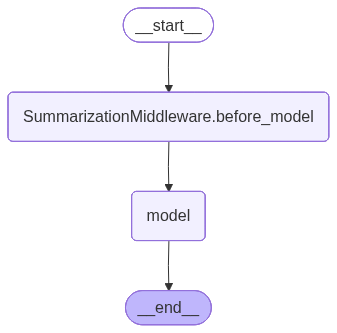

In [14]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))